# Ten-state average-reward malware IRL

This notebook implements a linear maximum entropy inverse reinforcement learning procedure for a ten-state malware spread model under the average-reward criterion.

The state space is

$$
\mathcal X=\{0,0.1,\ldots,0.9\},
$$

where each state represents the malware severity level of an agent. The action space is

$$
\mathcal A=\{0,1\},
$$

where $0$ means doing nothing and $1$ means repairing the system.

The notebook has two parts. First, it solves the forward stationary mean-field game under a known reward and computes the synthetic expert MFE $(\pi_E,\mu_E)$. Second, it uses the expert mean field and the expert feature expectation to solve the linear maximum entropy IRL problem.

The code is organized so that the numerical choices are made in the next cell, while the model primitives and solvers are imported from the Python file.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path

# Notebook is in: IRL-MFG/notebooks
# Python in: IRL-MFG/src
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from linear_malware_ten_states import (
    STATES,
    ACTIONS,
    normalize_probability,
    transition_fn,
    reward_fn,
    feature_vector,
    mean_field_average,
    solve_forward_mfe,
    occupation_measure_from_mu_pi,
    feature_expectation_from_nu,
    solve_linear_dual_irl,
    print_policy_table,
    print_state_vector,
    print_summary,
    plot_dual_objective,
    plot_gradient_norm,
    plot_policy_evolution,
    plot_final_policy_comparison,
)

np.set_printoptions(precision=6, suppress=True)

# Adjustable parameters

This cell fixes the numerical parameters used in the experiment.

The vector `THETA` contains positive cost coefficients. The reward used by the forward model is

$$
r(x,a,\mu)
=
-\left(
\theta_1 x+\theta_2 x\mu_{\mathrm{av}}+\theta_3 a
\right),
$$

where

$$
\mu_{\mathrm{av}}
=
\sum_{z\in\mathcal X}z\mu(z).
$$

Thus, larger malware severity, larger average malware severity in the population, and choosing repair all decrease the reward.

The initial mean-field term is chosen as the uniform distribution on $\mathcal X$. The forward MFE parameters control the fixed-point iteration for the mean field and the relative value iteration used to solve the frozen average-reward control problem.

The parameters `STEP_SIZE`, `N_ITER`, and `RECORD_EVERY` control the dual gradient descent algorithm used in the inverse problem. The list `STATES_TO_PLOT` only determines which states are shown in the optional policy-evolution plot. It does not affect the optimization.

In [2]:
# Reward parameter in r(x,a,mu) = -(theta_1 x + theta_2 x mu_av + theta_3 a)
THETA = np.array([0.10, 1.00, 0.40], dtype=float)

# Initial mean-field term for the forward MFE solver
MU0 = np.ones(len(STATES), dtype=float) / len(STATES)

# Forward MFE solver parameters
MAX_OUTER_ITER = 10000
TOL_MF = 1e-12
DAMPING = 1.0
MAX_INNER_ITER = 10000
TOL_MDP = 1e-12
X_REF = 0

# Dual IRL solver parameters
STEP_SIZE = 0.05
N_ITER = 80000
RECORD_EVERY = 100

# States shown in policy-evolution plot
STATES_TO_PLOT = [0, 3, 4, 5, 6, 9]

print("THETA =", THETA)
print("STATES =", STATES)
print("ACTIONS =", ACTIONS)

THETA = [0.1 1.  0.4]
STATES = [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
ACTIONS = [0 1]


# Forward MFE computation

This cell computes the expert pair $(\pi_E,\mu_E)$ by solving the forward stationary mean-field game.

For a fixed mean-field term $\mu$, the representative-agent average-reward control problem is solved by relative value iteration. The action-value expression is

$$
Q(x,a)
=
r(x,a,\mu)
+
\sum_y p(y\mid x,a,\mu)h(y),
$$

and the average-reward Bellman equation is

$$
\rho+h(x)
=
\max_a Q(x,a).
$$

The bias function $h$ is normalized by fixing a reference state, since in the average-reward setting $h$ is defined only up to an additive constant.

After solving the frozen control problem, the code extracts the greedy policy

$$
\pi_\mu(a\mid x)>0
\quad\Longleftrightarrow\quad
a\in\arg\max_b Q(x,b).
$$

Then the transition matrix induced by this policy is formed as

$$
P_{\pi_\mu}^{\mu}(y\mid x)
=
\sum_a
\pi_\mu(a\mid x)p(y\mid x,a,\mu).
$$

The corresponding invariant distribution $\hat\mu$ is computed from

$$
\hat\mu^\top P_{\pi_\mu}^{\mu}
=
\hat\mu^\top.
$$

The forward fixed-point iteration repeats these two steps until $\hat\mu\approx\mu$. At convergence, the returned pair satisfies the numerical MFE conditions: $\pi_E$ is optimal for the fixed mean field $\mu_E$, and $\mu_E$ is invariant under the transition matrix induced by $\pi_E$.

In [3]:
forward_results = solve_forward_mfe(
    mu0=MU0,
    theta=THETA,
    max_outer_iter=MAX_OUTER_ITER,
    tol_mf=TOL_MF,
    damping=DAMPING,
    max_inner_iter=MAX_INNER_ITER,
    tol_mdp=TOL_MDP,
    x_ref=X_REF,
    verbose=False,
)

mu_E = forward_results["mu_E"]
pi_E = forward_results["pi_E"]
nu_E = forward_results["nu_E"]
phi_exp_E = forward_results["phi_exp_E"]

print_state_vector(mu_E, title="Expert mean-field term mu_E")
print()
print_policy_table(pi_E, title="Expert policy pi_E")
print()
print_summary(forward_results)

Expert mean-field term mu_E
state  0.0: 0.40468276
state  0.1: 0.04552681
state  0.2: 0.05203064
state  0.3: 0.06070241
state  0.4: 0.07284290
state  0.5: 0.07284290
state  0.6: 0.07284290
state  0.7: 0.07284290
state  0.8: 0.07284290
state  0.9: 0.07284290

Expert policy pi_E
state | pi(do nothing) | pi(repair)
------|----------------|-----------
 0.0  |       1.000000 |  0.000000
 0.1  |       1.000000 |  0.000000
 0.2  |       1.000000 |  0.000000
 0.3  |       1.000000 |  0.000000
 0.4  |       1.000000 |  0.000000
 0.5  |       0.000000 |  1.000000
 0.6  |       0.000000 |  1.000000
 0.7  |       0.000000 |  1.000000
 0.8  |       0.000000 |  1.000000
 0.9  |       0.000000 |  1.000000

Forward MFE summary
MFE fixed-point residual: 0.0
Bellman residual: 8.626432901337466e-14
average reward rho_E: -0.27806337120758207
mean malware severity: 0.3172568290215352


# Expert statistics used by IRL

This cell prints the expert statistics used by the inverse problem.

The expert occupation measure is

$$
\nu_E(x,a)
=
\mu_E(x)\pi_E(a\mid x).
$$

This gives the long-run frequency with which the expert MFE visits each state-action pair.

The linear feature map is

$$
\varphi(x,a,\mu)
=
\left(
x,\,
x\mu_{\mathrm{av}},\,
a
\right).
$$

The first component measures the agent's own malware severity. The second component measures the interaction between the agent's severity and the average severity in the population. The third component records whether the repair action is chosen.

The expert feature expectation is computed as

$$
\langle \varphi\rangle_E
=
\sum_{x,a}
\nu_E(x,a)\varphi(x,a,\mu_E).
$$

This vector is the feature-matching target in the maximum entropy IRL problem. The inverse problem does not use the true reward parameter directly. It uses the expert mean field $\mu_E$ and the expert feature expectation $\langle\varphi\rangle_E$.

In [4]:
print("Expert occupation measure nu_E:")
print(nu_E)
print()
print("Expert feature expectation <f>_E:")
print(phi_exp_E)

Expert occupation measure nu_E:
[[0.404683 0.      ]
 [0.045527 0.      ]
 [0.052031 0.      ]
 [0.060702 0.      ]
 [0.072843 0.      ]
 [0.       0.072843]
 [0.       0.072843]
 [0.       0.072843]
 [0.       0.072843]
 [0.       0.072843]]

Expert feature expectation <f>_E:
[0.317257 0.100652 0.364214]


# Dual IRL solve

This cell solves the dual linear maximum entropy IRL problem by gradient descent.

The dual variables have three roles. The vector $\alpha$ corresponds to the feature-matching constraint. The vector $\beta$ corresponds to the flow-balance constraint. The vector $\eta$ corresponds to the marginal constraint. In the code, this last variable is called `theta_dual`; it is a dual multiplier and should not be confused with the reward-cost parameter `THETA`.

For each state-action pair, the code forms the exponent

$$
k(x,a)
=
\log\mu_E(x)
+
\alpha\cdot\varphi(x,a,\mu_E)
+
\eta_x
+
\beta\cdot
\left(
p(\cdot\mid x,a,\mu_E)-\mu_E
\right).
$$

The corresponding occupation measure is obtained by normalization:

$$
\nu(x,a)
=
\frac{\exp(k(x,a))}
{\sum_{y,b}\exp(k(y,b))}.
$$

This is the maximum entropy form of the recovered occupation measure.

The dual objective is

$$
h(\alpha,\beta,\eta)
=
\log\sum_{x,a}\exp(k(x,a))
-
\alpha\cdot\langle\varphi\rangle_E
-
\eta\cdot\mu_E.
$$

The gradient components are exactly the residuals of the inverse constraints. In particular,

$$
\nabla_\alpha h
=
\sum_{x,a}\nu(x,a)\varphi(x,a,\mu_E)
-
\langle\varphi\rangle_E,
$$

which is the feature-moment mismatch. The $\beta$-gradient is the flow-balance residual, and the $\eta$-gradient is the marginal mismatch

$$
\nu^{\mathcal X}-\mu_E.
$$

Thus, gradient descent on $h$ tries to find an occupation measure that matches the expert feature expectation, satisfies the stationary flow constraint, and has state marginal $\mu_E$.

In [5]:
irl_results = solve_linear_dual_irl(
    mu_E=mu_E,
    pi_E=pi_E,
    phi_exp_E=phi_exp_E,
    step_size=STEP_SIZE,
    n_iter=N_ITER,
    record_every=RECORD_EVERY,
    verbose=True,
    print_every=20000,
)

pi_rec = irl_results["pi_rec"]
mu_rec = irl_results["mu_rec"]
nu_rec = irl_results["nu_rec"]
phi_rec = irl_results["phi_rec"]

iter = 0 | h = 0.6931471805599453 | grad norm = 0.1970691080529521 | policy error = 0.5
iter = 20000 | h = 0.0739251636075241 | grad norm = 0.0072683849781708795 | policy error = 0.3193140135420045
iter = 40000 | h = 0.04414680154255024 | grad norm = 0.004135897429436944 | policy error = 0.21786558450610938
iter = 60000 | h = 0.03198280555651173 | grad norm = 0.002948237339852116 | policy error = 0.167165877142514


# Recovery summary

This cell displays the final recovered objects and the main numerical diagnostics.

The dual solver returns a recovered occupation measure $\nu^\star$. The recovered policy is obtained by disintegration:

$$
\pi^\star(a\mid x)
=
\frac{\nu^\star(x,a)}
{\nu^{\star,\mathcal X}(x)},
\qquad
\nu^{\star,\mathcal X}(x)
=
\sum_a \nu^\star(x,a).
$$

The recovered state marginal is

$$
\mu^\star(x)
=
\sum_a \nu^\star(x,a).
$$

If the dual optimization is successful, then $\mu^\star$ should be close to $\mu_E$, and the recovered feature expectation

$$
\langle\varphi\rangle_{\nu^\star}
=
\sum_{x,a}
\nu^\star(x,a)\varphi(x,a,\mu_E)
$$

should be close to the expert feature expectation $\langle\varphi\rangle_E$.

The printed gradient norm measures the remaining violation of the dual first-order condition. The feature error measures the feature-moment mismatch. The marginal error measures the difference between $\mu^\star$ and $\mu_E$. The flow error measures how well the recovered occupation measure satisfies the stationarity constraint.

The policy error compares the recovered maximum entropy policy $\pi^\star$ with the expert greedy policy $\pi_E$. Since the recovered policy is obtained from an entropy-regularized inverse problem, exact equality with a deterministic expert policy is not expected. The relevant question is whether $\pi^\star$ assigns high probability to the expert actions and reproduces the expert stationary statistics.

In [6]:
print_policy_table(pi_rec, title="Recovered policy pi_rec")
print()
print_state_vector(mu_rec, title="Recovered state marginal mu_rec")
print()
print_summary(forward_results, irl_results)
print()
print("Recovered feature expectation <f>_rec:")
print(phi_rec)
print()
print("Expert feature expectation <f>_E:")
print(phi_exp_E)

Recovered policy pi_rec
state | pi(do nothing) | pi(repair)
------|----------------|-----------
 0.0  |       0.994762 |  0.005238
 0.1  |       0.994921 |  0.005079
 0.2  |       0.990488 |  0.009512
 0.3  |       0.976098 |  0.023902
 0.4  |       0.890223 |  0.109777
 0.5  |       0.136143 |  0.863857
 0.6  |       0.018305 |  0.981695
 0.7  |       0.003995 |  0.996005
 0.8  |       0.001068 |  0.998932
 0.9  |       0.000279 |  0.999721

Recovered state marginal mu_rec
state  0.0: 0.40477120
state  0.1: 0.04564439
state  0.2: 0.05214266
state  0.3: 0.06079232
state  0.4: 0.07285509
state  0.5: 0.07269286
state  0.6: 0.07273861
state  0.7: 0.07276484
state  0.8: 0.07278786
state  0.9: 0.07281018

Forward MFE summary
MFE fixed-point residual: 0.0
Bellman residual: 8.626432901337466e-14
average reward rho_E: -0.27806337120758207
mean malware severity: 0.3172568290215352

IRL recovery summary
final gradient norm: 0.0023060939094367073
feature error: 0.0003353056884000683
marginal erro

# Plots

This cell visualizes the main numerical outputs of the inverse problem.

The first plot shows the dual objective value

$$
h(\alpha_k,\beta_k,\eta_k)
$$

along the gradient descent iterations. Since the algorithm minimizes the dual objective, a decreasing curve indicates that the optimization is progressing.

The gradient-norm plot is included as an optional diagnostic. It displays

$$
\|\nabla h(\alpha_k,\beta_k,\eta_k)\|.
$$

This quantity summarizes the remaining feature, flow, and marginal residuals. A small gradient norm indicates that the recovered occupation measure is close to satisfying the inverse constraints.

The policy-evolution plot is also optional. It shows selected entries of the recovered policy during optimization. This is useful for checking how the recovered repair probabilities change as the dual variables are updated.

The final plot compares the expert and recovered repair probabilities across all malware severity levels. For each state $x$, it compares

$$
\pi_E(1\mid x)
\qquad
\text{and}
\qquad
\pi^\star(1\mid x).
$$

This is the most direct visual comparison of the recovered behavior with the expert behavior. In the paper, this plot should be read together with the dual objective plot and the numerical errors printed in the previous cell.

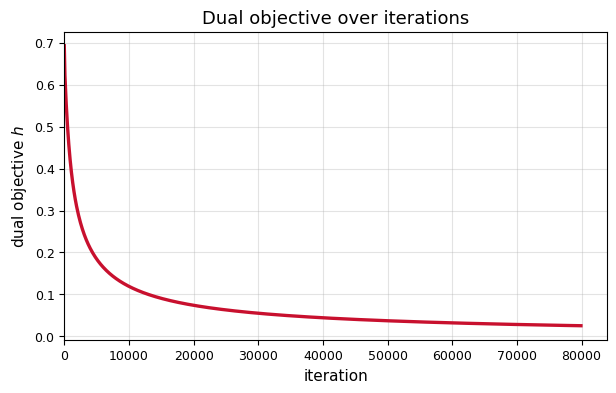

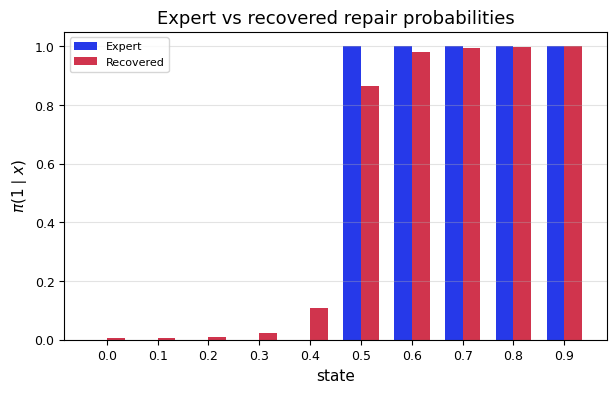

In [7]:
plot_dual_objective(irl_results)
plt.show()

# Plot of the gradient norm of h
"""
plot_gradient_norm(irl_results)
plt.show()
"""

# Plot of some selected policy evolutions
"""
plot_policy_evolution(irl_results, states_to_plot=STATES_TO_PLOT)
plt.show()
"""

plot_final_policy_comparison(irl_results)
plt.show()